# 04 — xG-RAPM, penalties stripped, plus a finishing overlay

Goals are a low-frequency, high-variance readout of match control. Expected
goals (xG) measures the *quality of chances created and conceded* — it is far
less noisy per minute and is standard practice for this family of models. The
design matrix is identical; only the response changes: stint **non-penalty** xG
differential per 90 (a penalty is ~0.76 xG awarded to the whole lineup — an
individual event, not collective play, so it is excluded here and handled by
the finishing overlay below).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from plimpact.config import load_config
from plimpact.validate import load_tables

cfg = load_config()
tables = load_tables(cfg)
matches, appearances, shots, stints = (
    tables["matches"], tables["appearances"], tables["shots"], tables["stints"]
)
pd.set_option("display.width", 120)

{'lambda': 3200.0,
 'home_advantage': 0.28216420448536483,
 'man_diff_coef': 1.0018619948191478,
 'replacement_coef': -0.17916678967363547,
 'controls': {'lead1': -0.13301841216704843,
  'lead2': -0.0769156934961735,
  'trail1': 0.11570030772973476,
  'trail2': -0.04364315572079439,
  'mid': 0.021318110881405457,
  'late': 0.07295550357697528}}

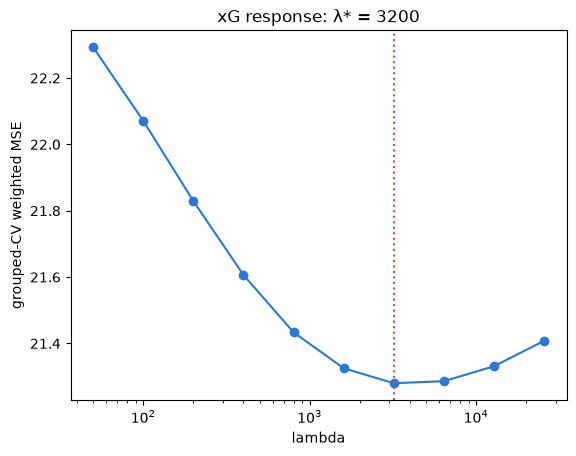

In [2]:
import json
cv = pd.read_parquet(cfg.processed_dir / "cv_curves.parquet")
meta = json.load(open(cfg.processed_dir / "model_meta.json"))
x = cv[cv["response"] == "xg"]
ax = x.plot(x="lambda", y="cv_mse", logx=True, marker="o", color="#2a78d6",
            legend=False, grid=False)
ax.axvline(meta["xg"]["lambda"], color="#e34948", linestyle=":")
ax.set_ylabel("grouped-CV weighted MSE")
ax.set_title(f"xG response: λ* = {meta['xg']['lambda']:g}")
meta["xg"]

In [3]:
ratings = pd.read_parquet(cfg.processed_dir / "ratings.parquet")
cols = ["player", "latest_team", "total_minutes", "rapm_xg",
        "rapm_xg_lo", "rapm_xg_hi", "rapm_goals", "naive_gd90"]
ratings.sort_values("rapm_xg", ascending=False).head(20)[cols].round(3)

,player,latest_team,total_minutes,rapm_xg,rapm_xg_lo,rapm_xg_hi,rapm_goals,naive_gd90
474,Bruno Guimarães,Newcastle United,9133,0.328,0.194,0.431,0.189,1.425
538,Kevin Schade,Brentford,5445,0.242,0.117,0.358,0.155,0.817
312,Jacob Murphy,Newcastle United,5314,0.236,0.101,0.375,0.202,0.746
239,Rodri,Manchester City,4564,0.235,0.120,0.350,0.251,0.555
371,William Saliba,Arsenal,9139,0.215,0.135,0.293,0.263,1.047
225,Trent Alexander-Arnold,Liverpool,4617,0.214,0.100,0.346,0.184,0.822
521,Rúben Dias,Manchester City,7012,0.213,0.099,0.336,0.188,0.377
588,Beto,Everton,4008,0.208,0.064,0.330,0.027,0.191
257,Callum Wilson,West Ham,2537,0.204,0.053,0.342,0.089,0.471
49,Kaoru Mitoma,Brighton,5854,0.201,0.080,0.320,0.146,0.588


## How much do the three methods agree?

In [4]:
from scipy.stats import spearmanr

r = ratings.dropna(subset=["naive_gd90"])
methods = {"naive": r["naive_gd90"], "RAPM (goals)": r["rapm_goals"],
           "RAPM (xG)": r["rapm_xg"]}
corr = pd.DataFrame(
    {a: {b: spearmanr(va, vb).statistic for b, vb in methods.items()}
     for a, va in methods.items()}
)
corr.round(2)

,naive,RAPM (goals),RAPM (xG)
naive,1.00,0.71,0.43
RAPM (goals),0.71,1.00,0.64
RAPM (xG),0.43,0.64,1.00


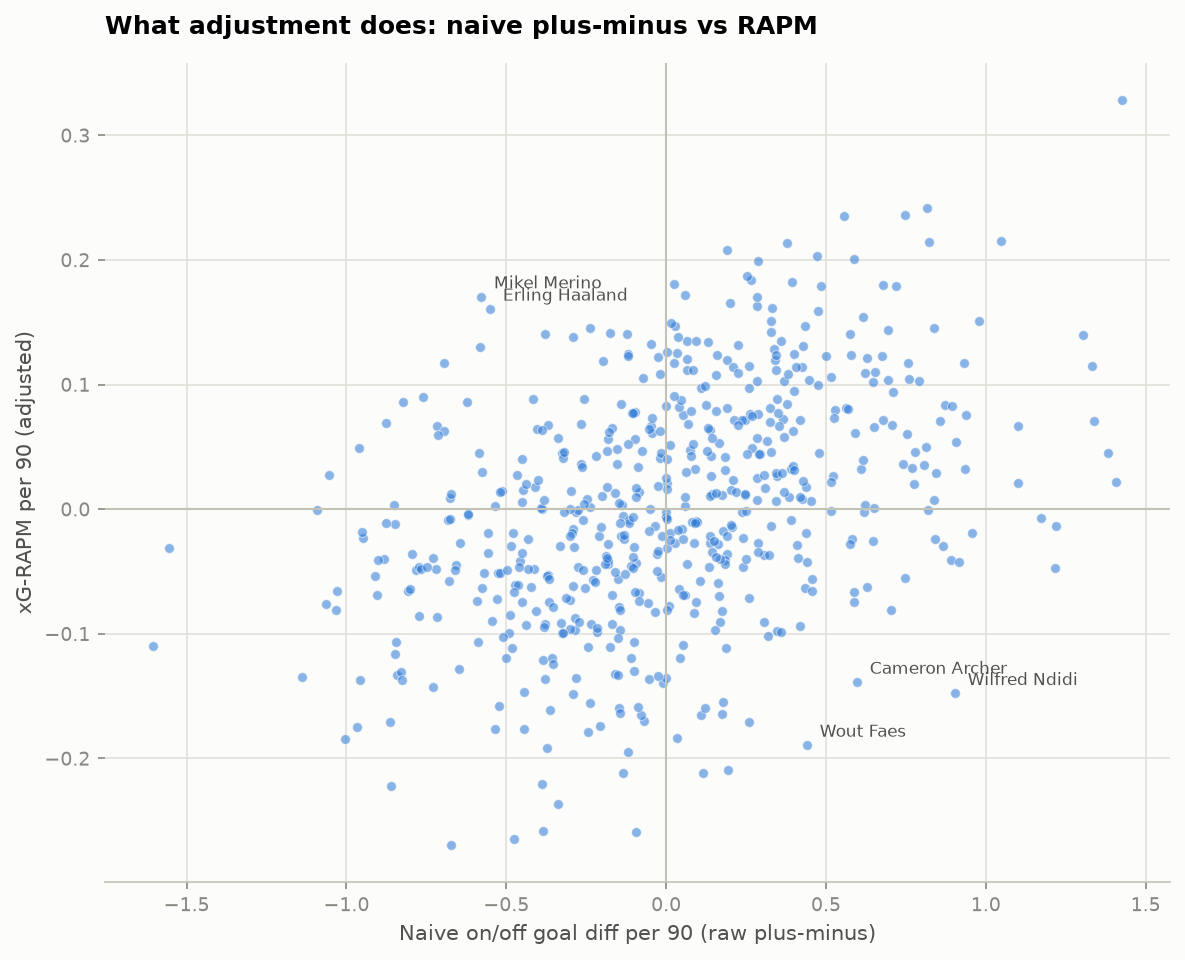

In [5]:
from plimpact.viz import fig_naive_vs_rapm
fig_naive_vs_rapm(ratings, cfg.outputs_dir / "naive_vs_rapm.png")
from IPython.display import Image
Image(str(cfg.outputs_dir / "naive_vs_rapm.png"), width=760)

The two RAPM variants correlate strongly with each other and only moderately
with the naive metric — the adjustment is doing real work. Which response is
more reliable is an empirical question, tested in the next notebook.

## The finishing overlay: crediting clinical finishers

A fair objection to xG ratings: *a wasteful striker shouldn't rank level with a
clinical one*. Switching the whole regression to goals doesn't fix that — a
goal credits all 11 players, so finishing skill smears across the lineup. The
right tool is individual: each player's **own** goals minus xG per shot, shrunk
toward zero with an empirical-Bayes prior (raw over/under-performance is mostly
luck; the shrinkage keeps only what the sample size supports). The prior
variance τ² is estimated from the data — finishing skill is real but small,
about ±0.01 goals per shot at one standard deviation, consistent with the
literature.

**Headline metric:** `impact90 = npxG-RAPM + finishing_per90`.

In [6]:
import json
meta = json.load(open(cfg.processed_dir / "model_meta.json"))
ratings = pd.read_parquet(cfg.processed_dir / "ratings.parquet")
print(f"tau^2 = {meta['finishing_tau2']:.6f}  (tau = {meta['finishing_tau2']**.5:.4f} goals/shot)")
fcols = ["player", "latest_team", "shots", "finishing_per90"]
print("\nMost clinical (shrunk):")
print(ratings.nlargest(8, "finishing_per90")[fcols].round(3).to_string(index=False))
print("\nMost wasteful (shrunk):")
print(ratings.nsmallest(8, "finishing_per90")[fcols].round(3).to_string(index=False))

tau^2 = 0.000101  (tau = 0.0101 goals/shot)

Most clinical (shrunk):
            player       latest_team  shots  finishing_per90
     Matheus Cunha Manchester United  273.0            0.039
      Harry Wilson            Fulham  160.0            0.026
        Phil Foden   Manchester City  214.0            0.025
        Jhon Durán       Aston Villa   51.0            0.023
     Michael Olise    Crystal Palace   56.0            0.021
Callum Hudson-Odoi Nottingham Forest  105.0            0.016
      Jarrod Bowen          West Ham  251.0            0.014
 Eli Junior Kroupi       Bournemouth   52.0            0.012

Most wasteful (shrunk):
               player     latest_team  shots  finishing_per90
Dominic Calvert-Lewin           Leeds  196.0           -0.034
         Darwin Núñez       Liverpool  142.0           -0.033
   Alejandro Garnacho         Chelsea  217.0           -0.030
         David Brooks     Bournemouth   86.0           -0.028
            Evanilson     Bournemouth  145.0   

In [7]:
cols = ["player", "latest_team", "position", "total_minutes",
        "rapm_xg", "finishing_per90", "impact90"]
ratings.sort_values("impact90", ascending=False).head(20)[cols].round(3)

,player,latest_team,position,total_minutes,rapm_xg,finishing_per90,impact90
474,Bruno Guimarães,Newcastle United,MID,9133,0.328,0.007,0.335
239,Rodri,Manchester City,MID,4564,0.235,0.009,0.244
538,Kevin Schade,Brentford,FWD,5445,0.242,-0.003,0.239
312,Jacob Murphy,Newcastle United,FWD,5314,0.236,0.003,0.239
225,Trent Alexander-Arnold,Liverpool,DEF,4617,0.214,0.005,0.219
371,William Saliba,Arsenal,DEF,9139,0.215,-0.000,0.215
521,Rúben Dias,Manchester City,DEF,7012,0.213,-0.002,0.212
257,Callum Wilson,West Ham,FWD,2537,0.204,-0.005,0.198
49,Kaoru Mitoma,Brighton,FWD,5854,0.201,-0.006,0.195
588,Beto,Everton,FWD,4008,0.208,-0.017,0.191
